In [2]:
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

In [3]:
import numpy as np
import os, glob, pickle, yaml

from matplotlib import pyplot as plt
from pylab import *

In [4]:
import sys
sys.path.append('./code')

In [5]:
import torch 
from torch.utils.data import DataLoader
from models import XASLightningModule
from data import XASGraphDataset, collate_fn

In [6]:
from pymatgen.io.ase import AseAtomsAdaptor
from collections import Counter

In [7]:
import umap

/hpcgpfs01/scratch/ccao/envs/ml-xas/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-29 16:35:11.189517: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-29 16:35:13.908531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-29 16:35:34.868582: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may

In [8]:
ROOT_PATH = './'

In [9]:
nblocks, cutoff, threebody_cutoff = 3, 4.0, 4.0

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
with open(ROOT_PATH + "/configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [12]:
GRID=np.linspace(9500-600, 9650-600, 1000)
energy_grid = GRID[333:733:2]

In [13]:
r1, r2, rZn = 3.0, 5.0, 4.2

### 1. Load data

In [14]:
structures = pickle.load(open(ROOT_PATH + '/dataset/all_structures.pkl', 'rb'))

In [15]:
spectra = torch.load(ROOT_PATH + "/dataset/all_spectra.pt")

### 2. Get neighbor counts

In [16]:
def get_neighbors(structure, r1=3.0, r2=5.0, rZn=4.2):
    atoms = AseAtomsAdaptor.get_atoms(structure)
    zn_idx = 0

    # Get first neighbors (nearest neighbors)
    first_neighbors = structure.get_neighbors(structure[zn_idx], r=r1)  # Using 3.0 Angstrom cutoff
    first_neighbors = [neighbor for neighbor in first_neighbors if neighbor[0].specie.symbol != 'H']
    first_neighbor_species = [neighbor[0].specie.symbol for neighbor in first_neighbors]
    # Get second neighbors
    two_shells_neighbors = structure.get_neighbors(structure[zn_idx], r=r2)  # Using 5.0 Angstrom cutoff
    second_neighbors = [neighbor for neighbor in two_shells_neighbors if neighbor[0].specie.symbol != 'H' and neighbor[0] not in first_neighbors]
    second_neighbor_species = [neighbor[0].specie.symbol for neighbor in second_neighbors]
    
    Zn_shell_neighbors = structure.get_neighbors(structure[zn_idx], r=rZn)  # Using 5.0 Angstrom cutoff
    Zn_neighbors = [neighbor for neighbor in Zn_shell_neighbors if neighbor[0].specie.symbol == 'Zn']
    Zn_neighbors_species = [neighbor[0].specie.symbol for neighbor in Zn_neighbors]
    
    c1 = Counter(first_neighbor_species)
    c2 = Counter(second_neighbor_species)
    cZn = Counter(Zn_neighbors_species)
    arr = []
    for key in ['Cl', 'O']:
        arr.append(c1[key])
    for key in ['Cl', 'O']:
        arr.append(c2[key])
    for key in ['Zn']:
        arr.append(cZn[key])
    return arr # return the coordination number of the structure with shape (5,), 5 are the coordination number of the Cl, O in the first shell, and Cl, O, Zn in the second shell.

In [17]:
cn_Cl = np.zeros(len(structures)) # list of coordination number of Cl in first shell
cn_O = np.zeros(len(structures)) # list of coordination number of O in first shell
cn_Cl_2nd = np.zeros(len(structures))
cn_O_2nd = np.zeros(len(structures))
cn_Zn = np.zeros(len(structures))

for idx, structure in enumerate(structures): 
        neighbors = get_neighbors(structure)
        cn_Cl[idx]=neighbors[0]
        cn_O[idx]=neighbors[1]
        cn_Cl_2nd[idx]=neighbors[2]
        cn_O_2nd[idx]=neighbors[3]
        cn_Zn[idx]=neighbors[4]

### 3. Convert structure into latent features

In [18]:
def cache_features(gnn, dataloader, save_path="absorber_features.pt", device="cuda"):
    gnn.eval().to(device)
    feats_all, spectra_all = [], []

    with torch.no_grad():
        for g, _, spectra in dataloader:
            g = g.to(device)
            spectra = spectra.to(device)
            feats = gnn(g)  # (B, d)
            feats_all.append(feats.cpu())
            spectra_all.append(spectra.cpu())

    feats_all = torch.cat(feats_all, dim=0)
    spectra_all = torch.cat(spectra_all, dim=0)
    torch.save((feats_all, spectra_all), save_path)
    print(f"Saved cached features to {save_path}")

In [19]:
dataset = XASGraphDataset(structures, spectra, cutoff=cutoff)
data_loader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

/hpcgpfs01/scratch/ccao/GNN-XAS-ZnCl2aq/./code/data.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.spectra.append(torch.tensor(spec, dtype=torch.float32))


In [20]:
gnn_config = dict(
    nblocks = config['gnn']['nblocks'], 
    cutoff = config['gnn']['cutoff'], 
    threebody_cutoff = config['gnn']['threebody_cutoff']
)

head_config = dict(
    hidden_dims = [64, 64], 
    output_size = config['head']['output_size'], 
    drop_rate = config['head']['drop_rate'], 
)

model = XASLightningModule(gnn_config, head_config, learning_rate=config['training']['lr'])

In [21]:
model.load_state_dict(torch.load(os.path.join('./model', "gnn.pth"), weights_only=True))

<All keys matched successfully>

In [22]:
# features_file = "absorber_features.pt"
# cache_features(model.gnn, data_loader, save_path="./all_" + features_file, device=device)

### 4. UMAP

In [22]:
features_file = "absorber_features.pt"
all_feats, all_spectra = torch.load("./data/all_" + features_file)

In [23]:
spectra = all_spectra.numpy()

In [24]:
umap_model = umap.UMAP(n_components=2, random_state=1)

In [25]:
umap_all = umap_model.fit_transform(all_feats)  # Reduce to 2D

/hpcgpfs01/scratch/ccao/envs/ml-xas/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
# np.save("./data/umap.npy", umap_all)

#### 4.1 UMAP - plot 

Text(0, 0.5, 'UMAP Dimension 2')

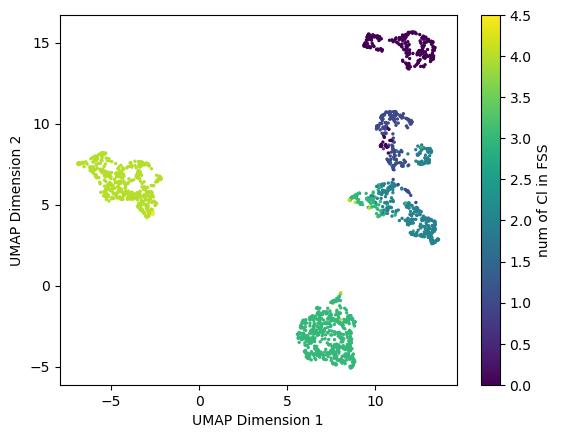

In [27]:
scatter = plt.scatter(umap_all[:, 0], umap_all[:, 1], s=2, c = cn_Cl, vmax=4.5)#, alpha=0.8)
plt.colorbar(label='num of Cl in FSS')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
# plt.savefig('./figures/UMAP-%s-%s-%s-Cl.png'%(nblocks, cutoff, threebody_cutoff), bbox_inches='tight', dpi=100)

Text(0, 0.5, 'UMAP Dimension 2')

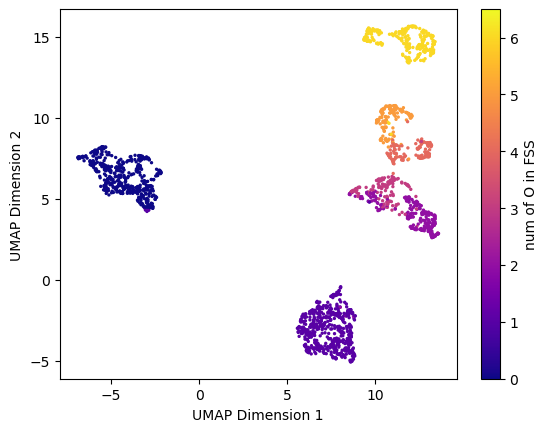

In [28]:
scatter = plt.scatter(umap_all[:, 0], umap_all[:, 1], s=2, c = cn_O, cmap='plasma', vmax=6.5)#, alpha=0.8)
plt.colorbar(label='num of O in FSS')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
# plt.savefig('./figures/UMAP-%s-%s-%s-O.png'%(nblocks, cutoff, threebody_cutoff), bbox_inches='tight', dpi=100)

Text(0, 0.5, 'UMAP Dimension 2')

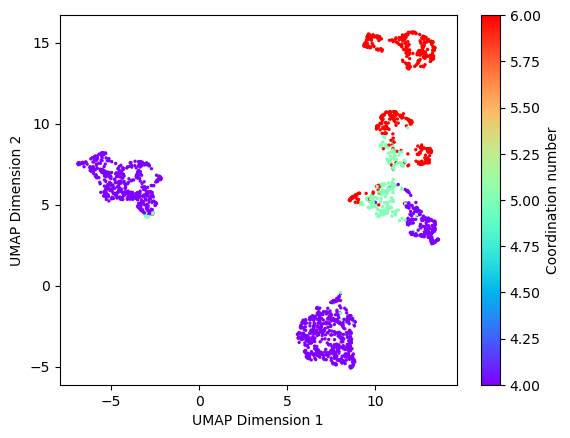

In [29]:
scatter = plt.scatter(umap_all[:, 0], umap_all[:, 1], s=2, c = cn_Cl+ cn_O, cmap='rainbow')#, alpha=0.8)
plt.colorbar(label='Coordination number')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
# plt.savefig('./figures/UMAP-%s-%s-%s-CN.png'%(nblocks, cutoff, threebody_cutoff), bbox_inches='tight', dpi=100)

### 5. UMAP - cluster

In [30]:
from sklearn.cluster import KMeans
import pandas as pd

In [31]:
X = umap_all  # from UMAP

In [32]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=2).fit(X)
original_cluster_labels = kmeans.labels_
original_centers = kmeans.cluster_centers_

In [33]:
df = pd.DataFrame({
    "cluster": original_cluster_labels,
    "nCl": cn_Cl,
    "nO": cn_O,
    "cn_total": cn_O+cn_Cl,
})

summary = df.groupby("cluster").agg(["mean", "std", "count"])
print(summary)

              nCl                        nO                  cn_total  \
             mean       std count      mean       std count      mean   
cluster                                                                 
0        1.197279  0.585833   294  4.551020  0.531386   294  5.748299   
1        4.012270  0.127446   489  0.012270  0.110201   489  4.024540   
2        3.011029  0.104536   544  1.007353  0.085512   544  4.018382   
3        0.000000  0.000000   278  6.000000  0.000000   278  6.000000   
4        2.014423  0.183323   208  2.028846  0.194451   208  4.043269   
5        2.467005  0.688964   197  2.700508  0.491405   197  5.167513   

                         
              std count  
cluster                  
0        0.442511   294  
1        0.167586   489  
2        0.134453   544  
3        0.000000   278  
4        0.203953   208  
5        0.531997   197  


In [34]:
order = df.groupby("cluster")["nO"].mean().sort_values().index.tolist()[::-1]

In [35]:
# Build mapping from old label → rank order
mapping = {old: new for new, old in enumerate(order)}
cluster_labels = np.array([mapping[i] for i in original_cluster_labels])
centers = original_centers[order]

In [36]:
# np.savetxt("./data/CN-FSS-SSS.txt", 
#            np.column_stack((cn_Cl, cn_O, cn_Cl_2nd, cn_O_2nd, cn_Zn, cluster_labels)), 
#           header = "cn_Cl, cn_O, cn_Cl_2nd, cn_O_2nd, cn_Zn, cluster_labels")

#### Plot cluster

Text(0, 0.5, 'UMAP-2')

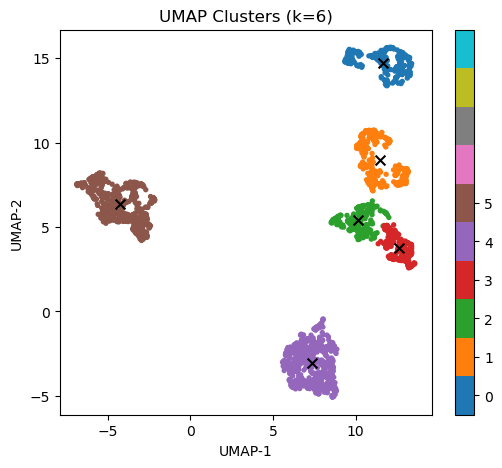

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=cluster_labels, cmap='tab10', s=8, vmin=-0.5, vmax=9.5)
plt.colorbar(ticks=np.arange(6))
plt.scatter(centers[:,0], centers[:,1], c='black', s=50, marker='x')
plt.title(f"UMAP Clusters (k={k})")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
# plt.savefig('./figures/UMAP-%s-%s-%s-clusters.png'%(nblocks, cutoff, threebody_cutoff), bbox_inches='tight', dpi=100)

In [38]:
nE = spectra.shape[1]
cluster_means = []
cluster_reps = []

for i in range(k):
    idx = np.where(cluster_labels == i)[0]
    mean_spec = spectra[idx].mean(axis=0)
    cluster_means.append(mean_spec)

    # representative 
    dists = np.sum(mean_spec*spectra[idx], axis=1) / np.linalg.norm(mean_spec) / np.linalg.norm(spectra[idx], axis=1)
    rep_idx = idx[np.argmax(dists)]
    cluster_reps.append(rep_idx)

(8950.0, 9009.75975975976)

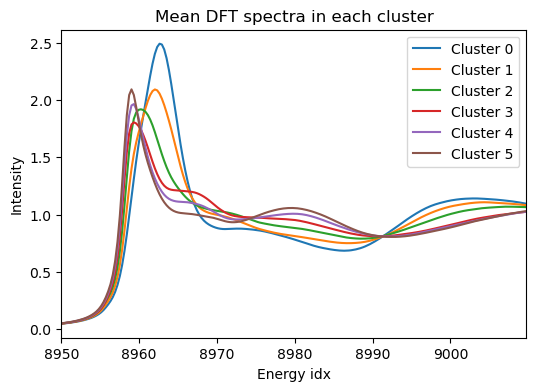

In [39]:
plt.figure(figsize=(6,4))
for i, mean_spec in enumerate(cluster_means):
    plt.plot(energy_grid, mean_spec, label=f"Cluster {i}")
# plt.xlabel("Energy (eV)")
plt.xlabel("Energy idx")
plt.ylabel("Intensity")
plt.legend()
plt.title("Mean DFT spectra in each cluster")
plt.xlim(energy_grid[0],energy_grid[-1])
# plt.savefig('./figures/UMAP-mean-sp.png', bbox_inches='tight', dpi=100)

(8950.0, 9009.75975975976)

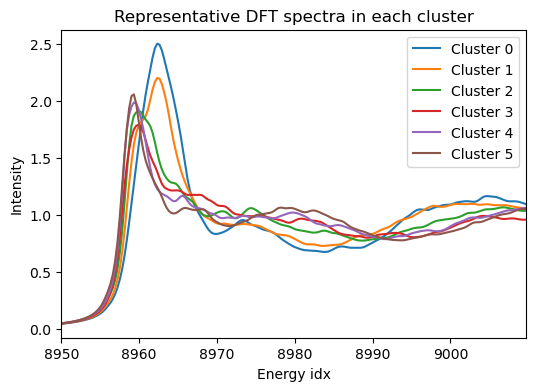

In [40]:
plt.figure(figsize=(6,4))
for i, rep_idx in enumerate(cluster_reps):
    plt.plot(energy_grid, spectra[rep_idx], label=f"Cluster {i}")
plt.xlabel("Energy idx")
plt.ylabel("Intensity")
plt.legend()
plt.title("Representative DFT spectra in each cluster")
plt.xlim(energy_grid[0],energy_grid[-1])
# plt.savefig('./figures/UMAP-rep-sp.png', bbox_inches='tight', dpi=100)

In [41]:
# for i, mean_spec in enumerate(cluster_means):
#     np.savetxt("./data/mean_spec-cluster_%s.txt"%i, np.column_stack((energy_grid, mean_spec)) )
# for i, rep_idx in enumerate(cluster_reps):
#     np.savetxt("./data/rep_spec-cluster_%s.txt"%i, np.column_stack((energy_grid, spectra[rep_idx])) )

In [42]:
df = pd.DataFrame({
    "cluster": cluster_labels,
    "nCl": cn_Cl,
    "nO": cn_O,
    "cn_total": cn_O+cn_Cl,
})

summary = df.groupby("cluster").agg(["mean", "std", "count"])
print(summary)

              nCl                        nO                  cn_total  \
             mean       std count      mean       std count      mean   
cluster                                                                 
0        0.000000  0.000000   278  6.000000  0.000000   278  6.000000   
1        1.197279  0.585833   294  4.551020  0.531386   294  5.748299   
2        2.467005  0.688964   197  2.700508  0.491405   197  5.167513   
3        2.014423  0.183323   208  2.028846  0.194451   208  4.043269   
4        3.011029  0.104536   544  1.007353  0.085512   544  4.018382   
5        4.012270  0.127446   489  0.012270  0.110201   489  4.024540   

                         
              std count  
cluster                  
0        0.000000   278  
1        0.442511   294  
2        0.531997   197  
3        0.203953   208  
4        0.134453   544  
5        0.167586   489  


In [43]:
cluster_summary = {
    'nCl-mean': summary['nCl']['mean'], 
    'nCl-std': summary['nCl']['std'], 
    'nO-mean': summary['nO']['mean'], 
    'nO-std': summary['nO']['std'], 
    'CN-mean': summary['cn_total']['mean'], 
    'CN-mean': summary['cn_total']['std'], 
    'rep-nCl': [cn_Cl[rep_idx] for rep_idx in cluster_reps], 
    'rep-nO': [cn_O[rep_idx] for rep_idx in cluster_reps], 
}

In [44]:
# pickle.dump(cluster_summary, open('./data/cluster_summary.pkl', 'wb'), protocol=4)

In [45]:
for i, rep_idx in enumerate(cluster_reps):
    structure = structures[rep_idx]
    print(i, rep_idx, cn_Cl[rep_idx], cn_O[rep_idx])


0 1955 0.0 6.0
1 923 1.0 5.0
2 1878 3.0 2.0
3 1210 2.0 2.0
4 1858 3.0 1.0
5 976 4.0 0.0


In [46]:
cluster_summary

{'nCl-mean': cluster
 0    0.000000
 1    1.197279
 2    2.467005
 3    2.014423
 4    3.011029
 5    4.012270
 Name: mean, dtype: float64,
 'nCl-std': cluster
 0    0.000000
 1    0.585833
 2    0.688964
 3    0.183323
 4    0.104536
 5    0.127446
 Name: std, dtype: float64,
 'nO-mean': cluster
 0    6.000000
 1    4.551020
 2    2.700508
 3    2.028846
 4    1.007353
 5    0.012270
 Name: mean, dtype: float64,
 'nO-std': cluster
 0    0.000000
 1    0.531386
 2    0.491405
 3    0.194451
 4    0.085512
 5    0.110201
 Name: std, dtype: float64,
 'CN-mean': cluster
 0    0.000000
 1    0.442511
 2    0.531997
 3    0.203953
 4    0.134453
 5    0.167586
 Name: std, dtype: float64,
 'rep-nCl': [0.0, 1.0, 3.0, 2.0, 3.0, 4.0],
 'rep-nO': [6.0, 5.0, 2.0, 2.0, 1.0, 0.0]}